# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

In [3]:
df = pd.read_csv("movies.csv", encoding='latin1')

In [4]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


# Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [6]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [7]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

# Data Cleaning

In [8]:
df = df.dropna()

# Select Important Columns

In [9]:
df = df[['Genre', 'Director', 'Actor 1', 'Duration', 'Votes', 'Rating']]

In [10]:
df.head()

,Genre,Director,Actor 1,Duration,Votes,Rating
1,Drama,Gaurav Bakshi,Rasika Dugal,109 min,8,7.0
3,"Comedy, Romance",Ovais Khan,Prateik,110 min,35,4.4
5,"Comedy, Drama, Musical",Rahul Rawail,Bobby Deol,147 min,827,4.7
6,"Drama, Romance, War",Shoojit Sircar,Jimmy Sheirgill,142 min,"1,086",7.4
8,"Horror, Mystery, Thriller",Allyson Patel,Yash Dave,82 min,326,5.6


# Convert Text Data to Numbers

In [22]:
# Remove ' min' from Duration and convert to integer
df['Duration'] = df['Duration'].str.replace(' min', '')
df['Duration'] = df['Duration'].astype(int)

# Remove commas from Votes and convert to integer
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')
df['Votes'] = df['Votes'].astype(int)

# Define Features and Target

In [23]:
X = df[['Genre', 'Director', 'Actor 1', 'Duration', 'Votes']]

In [24]:
y = df['Rating']

# Split Dataset

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model

In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Make Predictions

In [27]:
y_pred = model.predict(X_test)

# Evaluate Model


In [28]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.9924620141342757


In [29]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.2569893721913963


In [30]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.14673811080532784


# Visualization

Actual vs Predicted Ratings

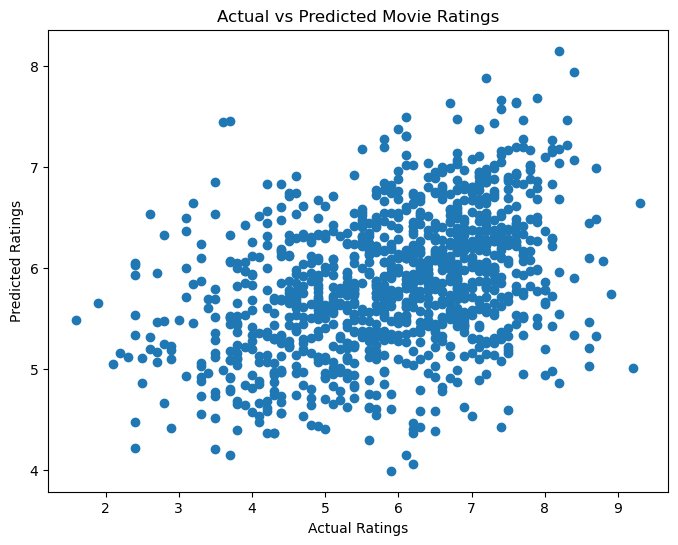

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()